# RESNET LEARNING

#### Previously:

you designed feature extractor

Now:

you reuse a pretrained feature extractor

This is modern practical CV.

## Step-by-step:

## Import pretrained ResNet18
## Understand architecture briefly
## Replace classifier layer
## Freeze pretrained layers
## Train only classifier
## Compare with old CNN
## Observe accuracy jump

## Import Libraries

In [2]:
import torch
from torch import nn
from torchvision import datasets,transforms
from torch.utils.data import DataLoader
from torchvision.models import resnet18
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# Your Old CNN
# You manually built:
# Conv
# → ReLU
# → Pool
# → Conv
# → Pool
# → Linear
# Very small network.

# -------------------------------------------------------------------------

# ResNet
# ResNet is also a CNN.
# But:
# MUCH deeper
# MUCH smarter architecture
# pretrained on massive datasets

# -------------------------------------------------------------------------

# ResNet still fundamentally uses:
# Conv2D
# ReLU
# Pooling
# Linear Layers
# So your previous learning still applies.

# -------------------------------------------------------------------------

# THE BIG DIFFERENCE

# ResNet has:

# skip connections

# ---------------------------------------------------------------------------

# What Are Skip Connections?

# Normally:

# input
# → layer1
# → layer2
# → output

# ResNet additionally does:

# input ─────────→ output

# shortcut path.

# ---------------------------------------------------------------------------

# WHY?

# Deep networks had problems:

# gradients vanished
# training unstable
# accuracy degraded

# Skip connections helped gradients flow properly.

# This enabled:

# very deep CNNs
# 50 layers
# 101 layers
# 152 layers

# ---------------------------------------------------------------------------

# MOST Important Intuition

# ResNet says:

# "If deeper layers are not useful,
# just preserve original information."

# This made deep learning much more stable.

# WHY TRANSFER LEARNING IS POWERFUL

# ResNet18 pretrained on ImageNet already learned:

# edges
# curves
# textures
# shapes
# object parts

# from:

# millions of images

# ---------------------------------------------------------------------------




# Device Setup

In [3]:
device= "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Create Better Transforms

In [4]:
# Now we use proper normalization.
transform=transforms.Compose([
  transforms.Resize((224,224)),
  transforms.ToTensor(),
  transforms.Normalize(
    mean=[0.485,0.456,0.406],
    std=[0.229,0.224,0.225]
  )
])

#------------------------------------------------------------------------------

# What Does Normalize Actually Do?
# For every pixel:


# Per Channel

# Applied separately to:

# Red
# Green
# Blue

# # Problem Without Normalization

# Different features may have wildly different scales.

# Example:

# Red channel average 200
# Blue channel average 20

# Network becomes biased toward large-valued features.

#------------------------------------------------------------------------------
# Why THESE Exact Numbers?
# mean=[0.485, 0.456, 0.406]
# std=[0.229, 0.224, 0.225]

# These are:

# ImageNet dataset statistics

# Computed over millions of images.
# ----------------------------------------------------------------------------

# Load CIFAR10

In [5]:
train_data=datasets.CIFAR10(
  root="data",
  train=True,
  download=True,
  transform=transform
)

test_data=datasets.CIFAR10(
  root="data",
  train=False,
  download=True,
  transform=transform
)

c:\Users\ahlaw\OneDrive\Desktop\PYTORCH\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


# Create DataLoaders

In [6]:
train_dataloader=DataLoader(
  train_data,
  batch_size=32,
  shuffle=True
)

test_dataloader=DataLoader(
  test_data,
  batch_size=32,
  shuffle=False
)

# LOAD PRETRAINED RESNET18

In [7]:
model=resnet18(pretrained=True)

# ----------------------------------------------------------------------------

# At this moment:

# you just loaded pretrained visual intelligence

# This model already knows:

# edges
# textures
# object structures
# spatial hierarchies

# -----------------------------------------------------------------------------

c:\Users\ahlaw\OneDrive\Desktop\PYTORCH\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\ahlaw\OneDrive\Desktop\PYTORCH\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


# Inspect Final Layer

In [8]:
print(model)

#--------------------------------------------------------------------------

# Near the end you’ll see something like:

# (fc): Linear(in_features=512, out_features=1000)
# WHY 1000?

# Because original ResNet predicts:

# 1000 ImageNet classes

# But CIFAR10 only has:

# 10 classes

# So we must replace classifier.

#----------------------------------------------------------------------------

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Replace Final Layer

In [9]:
model.fc=nn.Linear(
  in_features=512,
  out_features=10
)

# Move Model To GPU

In [10]:
model = model.to(device)
print(device)

cuda


## Freeze Pretrained Layers

In [11]:
for param in model.parameters() : 
  param.requires_grad=False;
  
# ---------------------------------------------------------------------------

# WHAT DOES THIS DO?

# It tells PyTorch:

# DO NOT update pretrained weights

# during training.

# Because:

# pretrained filters already good
# we don't want to destroy learned visual features initially.
# #------------------------------------------------------------------------------

# Right now:

# all pretrained CNN layers frozen.

# BUT:

# model.fc

# also got frozen accidentally.

# So we must re-enable gradients for final classifier.

# Unfreeze Final Layer

In [12]:
for param in model.fc.parameters() : 
  param.requires_grad=True;
  
# therefore now only the final classfiier learns  and every other pretrained feature stays fixed
# this is called feature extraction transfer learning

# Loss Function

In [13]:
loss_fn=nn.CrossEntropyLoss()

# Optimizer

In [14]:
optimizer=torch.optim.Adam(
  model.fc.parameters(),
  lr=0.001
)

# Verify Output Shape

In [15]:
X, y = next(iter(train_dataloader))

X = X.to(device)

output = model(X)

print(output.shape)

torch.Size([32, 10])


# Training Loop For ResNet18

In [16]:
epochs=5

train_loss_value=[]
test_loss_value=[]
epoch_count=[]

for epoch in range(epochs) : 
  # traininig
  model.train()
  train_loss=0
  
  for X,y in train_dataloader:
    X,y=X.to(device), y.to(device)
    y_logits=model(X)
    loss=loss_fn(y_logits,y)
    train_loss+=loss.item()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  train_loss/=len(train_dataloader)
  
  #testing
  model.eval()
  
  test_loss=0
  correct=0
  
  with torch.inference_mode():
    for X,y in test_dataloader:
      X,y=X.to(device), y.to(device)
      test_logits=model(X)
      loss=loss_fn(test_logits,y)
      test_loss+=loss.item()
      y_pred=torch.argmax(test_logits,dim=1)
      correct+=(y_pred==y).sum().item()
    test_loss/=len(test_dataloader)
    accuracy=correct/len(test_data)
    
    # store
    train_loss_value.append(train_loss)
    test_loss_value.append(test_loss)
    epoch_count.append(epoch+1)
    print(f"Epoch: {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Accuracy: {accuracy*100:.2f}%\n")
    

Epoch: 1
Train Loss: 0.8017
Test Loss: 0.6035
Accuracy: 79.67%

Epoch: 2
Train Loss: 0.6377
Test Loss: 0.5803
Accuracy: 80.39%

Epoch: 3
Train Loss: 0.6211
Test Loss: 0.5960
Accuracy: 79.89%

Epoch: 4
Train Loss: 0.6108
Test Loss: 0.5734
Accuracy: 80.52%

Epoch: 5
Train Loss: 0.6025
Test Loss: 0.5835
Accuracy: 80.08%



In [17]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


# Plot ResNet Loss Curves

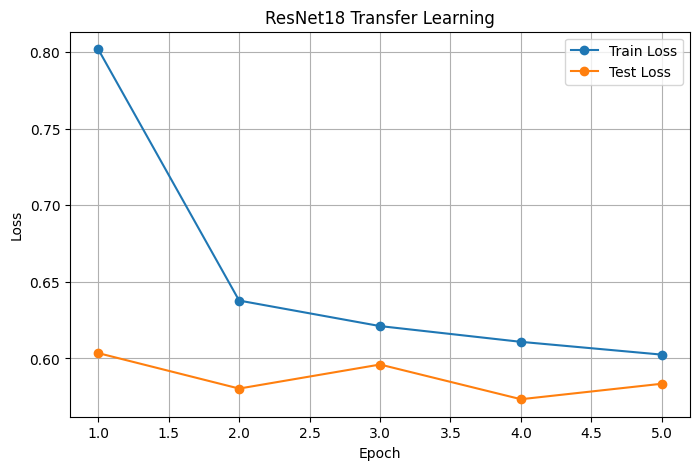

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(epoch_count,
         train_loss_value,
         marker='o',
         label="Train Loss")

plt.plot(epoch_count,
         test_loss_value,
         marker='o',
         label="Test Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ResNet18 Transfer Learning")

plt.legend()

plt.grid(True)

plt.show()

In [19]:
import pandas as pd

comparison = {

    "Model": [
        "Scratch CNN",
        "ResNet18 Transfer"
    ],

    "Accuracy": [
        50.78,
        80.52
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Scratch CNN,50.78
1,ResNet18 Transfer,80.52


# Plot Accuracy Comparison


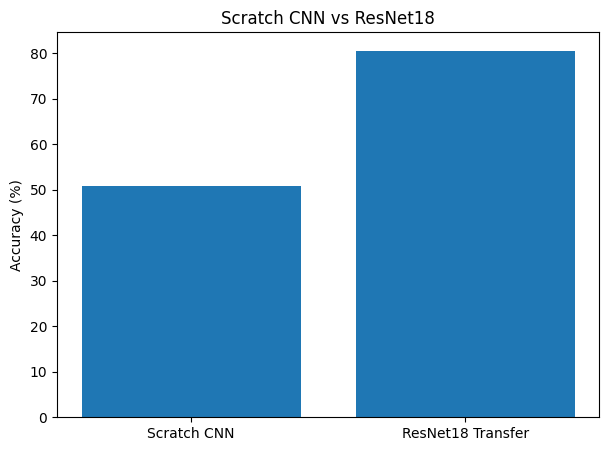

In [20]:
plt.figure(figsize=(7,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy (%)")

plt.title("Scratch CNN vs ResNet18")

plt.show()

# VISUALIZE PREDICTIONS

In [21]:
classes=train_data.classes
classes

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

# Get Batch

In [23]:
images, labels = next(iter(test_dataloader))

images = images.to(device)

labels = labels.to(device)

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


# Predict

In [24]:
model.eval()

with torch.inference_mode():

    outputs = model(images)

    preds = torch.argmax(outputs, dim=1)

# Visualize Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.05098039..1.0775862].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0576298].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015686303..1.0775862].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.14509803..1.005743].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0039215386..1.08956].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.082352936..1.0815775].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0745098..1.02

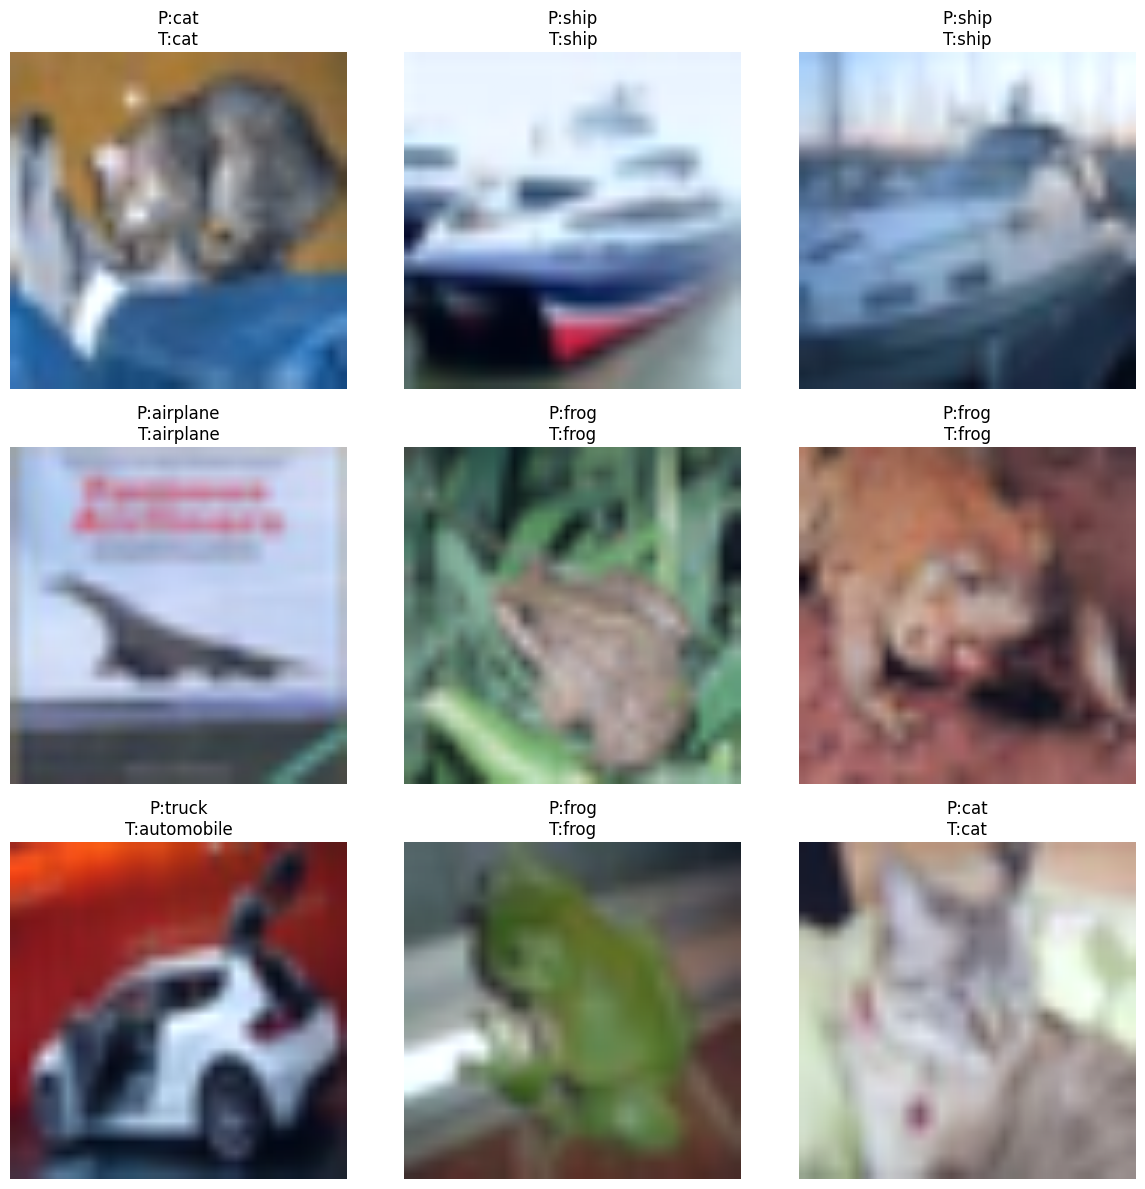

In [25]:
fig = plt.figure(figsize=(12,12))

for i in range(9):

    ax = fig.add_subplot(3,3,i+1)

    img = images[i].cpu()

    img = img.permute(1,2,0)

    img = img * 0.229 + 0.485

    ax.imshow(img)

    pred_label = classes[preds[i]]

    true_label = classes[labels[i]]

    ax.set_title(f"P:{pred_label}\nT:{true_label}")

    ax.axis(False)

plt.tight_layout()

plt.show()